# Patch-Based Binary Segmentation

> Patch-based training for 3D medical image segmentation using fastMONAI's `MedPatchDataLoaders` with **lazy loading** - volumes are loaded on-demand, keeping memory usage constant regardless of dataset size.

This tutorial demonstrates when and how to use patch-based training:

- **Large volumes**: When full images don't fit in GPU memory
- **Memory constraints**: Constant ~150 MB memory usage regardless of dataset size
- **Class imbalance**: Foreground-weighted sampling for better learning on small structures

We use the same Heart MRI dataset from the [binary segmentation tutorial](11d_tutorial_binary_segmentation.ipynb) for direct comparison.

[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MMIV-ML/fastMONAI/blob/main/nbs/12a_tutorial_patch_training.ipynb)

In [ ]:
#| hide
#Install `fastMONAI` if notebook is running on Google Colab
try:
    import google.colab
    %pip install fastMONAI
    from fastMONAI.utils import print_colab_gpu_info
    print_colab_gpu_info()
except:
    print('Running locally')

Running locally


In [ ]:
from fastMONAI.vision_all import *

from monai.apps import DecathlonDataset
from sklearn.model_selection import train_test_split

### Download external data

We use the MONAI function `DecathlonDataset` to download the Heart MRI dataset from the Medical Segmentation Decathlon challenge.

In [ ]:
path = Path('../data')
path.mkdir(exist_ok=True)

In [ ]:
task = "Task02_Heart"
training_data = DecathlonDataset(root_dir=path, task=task, section="training", 
    download=True, cache_num=0, num_workers=3)

2026-02-16 10:13:59,106 - INFO - Verified 'Task02_Heart.tar', md5: 06ee59366e1e5124267b774dbd654057.
2026-02-16 10:13:59,107 - INFO - File exists: ../data/Task02_Heart.tar, skipped downloading.
2026-02-16 10:13:59,107 - INFO - Non-empty folder exists in ../data/Task02_Heart, skipped extracting.


In [ ]:
df = pd.DataFrame(training_data.data)
df.shape

(16, 2)

Split the labeled data into training and test sets.

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
train_df.shape, test_df.shape

((14, 2), (2, 2))

### Analyze training data

Use `MedDataset` to analyze the dataset and get preprocessing recommendations.

In [ ]:
med_dataset = MedDataset(img_list=train_df.label.tolist(), dtype=MedMask, max_workers=12)

MedDataset cache: 14 cached, 0 processed


In [ ]:
med_dataset.df.head()

,path,content_hash,dim_0,dim_1,dim_2,voxel_0,voxel_1,voxel_2,orientation,label_1_volume_mm3
0,../data/Task02_Heart/labelsTr/la_023.nii.gz,a4b0e976cf03b0f1ffdbf79ae91281c4,320,320,110,1.25,1.25,1.37,RAS+,92483.5628
1,../data/Task02_Heart/labelsTr/la_004.nii.gz,db5dcb7cce258526726054f56bf015ef,320,320,110,1.25,1.25,1.37,RAS+,125173.0473
2,../data/Task02_Heart/labelsTr/la_007.nii.gz,4b1c1bf9d0d1adfb12d287c7aa200edc,320,320,130,1.25,1.25,1.37,RAS+,118684.8129
3,../data/Task02_Heart/labelsTr/la_022.nii.gz,f9c20e542980932d2ea19a56f3bc7a60,320,320,110,1.25,1.25,1.37,RAS+,71820.1096
4,../data/Task02_Heart/labelsTr/la_011.nii.gz,f1dd0a596e4daf898c3287441971cc06,320,320,120,1.25,1.25,1.37,RAS+,125130.2348


In [ ]:
data_info_df = med_dataset.summary()

In [ ]:
suggestion = med_dataset.get_suggestion()
target_spacing = suggestion['target_spacing']
target_spacing

[1.25, 1.25, 1.37]

In [ ]:
stats = med_dataset.get_size_statistics(target_spacing=target_spacing)
print(f"Image sizes (after resampling to {target_spacing}):")
print(f"  Min:    {stats['min']}")
print(f"  Median: {stats['median']}")
print(f"  Max:    {stats['max']}")

suggested_size = suggest_patch_size(med_dataset, target_spacing=target_spacing)
print(f"\nSuggested patch size: {suggested_size}")

Image sizes (after resampling to [1.25, 1.25, 1.37]):
  Min:    [320.0, 320.0, 90.0]
  Median: [320.0, 320.0, 110.0]
  Max:    [320.0, 320.0, 130.0]

Suggested patch size: [256, 256, 80]


Dim 2: patch_size reduced from 96 to 80 to fit smallest volume (min=90, median=110).


### Configure patch-based training

`PatchConfig` centralizes all patch-related parameters:

- **patch_size**: Size of extracted patches `[x, y, z]` - should be divisible by 16 for UNet compatibility
- **samples_per_volume**: Number of patches extracted per volume per epoch
- **sampler_type**: `'uniform'` (random) or `'label'` (foreground-weighted)
- **label_probabilities**: For `'label'` sampler, probability of sampling each class
- **queue_length**: Number of patches to keep in memory buffer
- **patch_overlap**: Overlap for inference (float 0-1 for fraction, or int for pixels)
- **aggregation_mode**: How to combine overlapping patches (`'hann'` for smooth boundaries)
- **padding_mode**: Padding mode when image < patch_size (0 = zero padding, nnU-Net standard)

In [ ]:
patch_config = PatchConfig(
    patch_size=[160, 160, 80],
    samples_per_volume=8,
    sampler_type='label',
    label_probabilities={0: 0.5, 1: 0.5},
    patch_overlap=0.5,
    keep_largest_component=True,
    target_spacing=target_spacing,
    aggregation_mode='hann'
    # apply_reorder defaults to True (the common case)
)

print(f"Patch config: {patch_config}")

Patch config: PatchConfig(patch_size=[160, 160, 80], patch_overlap=0.5, samples_per_volume=8, sampler_type='label', label_probabilities={0: 0.67, 1: 0.33}, queue_length=300, queue_num_workers=4, aggregation_mode='hann', apply_reorder=True, target_spacing=[1.25, 1.25, 1.37], padding_mode=0, keep_largest_component=True)


> **Alternative**: Use `PatchConfig.from_dataset(med_dataset)` to auto-configure patch size based on dataset analysis.

### Define transforms

Patch-based training uses **two stages** of transforms:

1. **pre_patch_tfms**: Applied to full volumes before patch extraction (e.g., normalization)
2. **patch_tfms**: Applied to extracted patches during training (augmentations)

> **Note**: `suggest_patch_size` ensures the recommended patch size fits all volumes
> in the dataset. No automatic padding is applied during training.

> **Critical**: `pre_patch_tfms` must match between training and inference for consistent preprocessing.

In [ ]:
# Pre-patch transforms (applied to full volumes by Queue workers)
pre_patch_tfms = [ZNormalization()]

patch_tfms = [
    RandomAffine(scales=(0.7, 1.4), degrees=30, translation=(25, 25, 10), p=0.2),
    RandomAnisotropy(downsampling=(1.5, 3), p=0.25),
    RandomGamma(log_gamma=(-0.3, 0.3), p=0.3),
    RandomIntensityScale(scale_range=(0.75, 1.25), p=0.1),
    RandomNoise(std=0.1, p=0.1),
    RandomBlur(std=(0.5, 1.0), p=0.2),
    RandomFlip(axes='LRAPIS', p=0.5),
]

### Create patch-based DataLoaders

`MedPatchDataLoaders` uses **lazy loading**:
- Only file paths are stored at creation time (~0 MB)
- Volumes are loaded on-demand by Queue workers

In [ ]:
bs = 4

dls = MedPatchDataLoaders.from_df(
    df=train_df,
    img_col='image',
    mask_col='label',
    valid_pct=0.1,
    patch_config=patch_config,
    pre_patch_tfms=pre_patch_tfms,
    patch_tfms=patch_tfms,
    bs=bs,
    seed=42
)

print(f"Training subjects: {len(dls.train.subjects_dataset)}")
print(f"Validation subjects: {len(dls.valid.subjects_dataset)}")

Training subjects: 13
Validation subjects: 1


In [ ]:
# Visualize a batch of patches
batch = next(iter(dls.train))
x, y = batch
print(f"Batch shape - Image: {x.shape}, Mask: {y.shape}")

Batch shape - Image: torch.Size([4, 1, 160, 160, 80]), Mask: torch.Size([4, 1, 160, 160, 80])


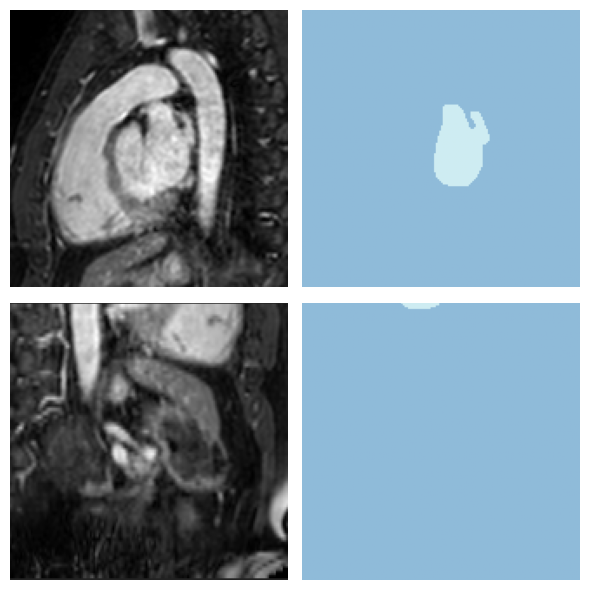

In [ ]:
dls.show_batch(anatomical_plane=2, max_n=2, overlay=False)

### Create and train a 3D model

We use MONAI's UNet with:
- **out_channels=2**: Softmax output (background + foreground)
- **Instance normalization**: Common in medical imaging
- **DiceCELoss**: Combines Dice loss with Cross-Entropy for stable training

In [ ]:
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.losses import DiceCELoss

In [ ]:
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.INSTANCE
)

loss_func = CustomLoss(loss_func=DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    include_background=True
))

We use `AccumulatedDice` metric which accumulates true positives, false positives, and false negatives across all validation batches before computing Dice.

In [ ]:
learn = Learner(dls, model, loss_func=loss_func, metrics=[AccumulatedDice(n_classes=2)])

SuggestedLRs(valley=0.004365158267319202)

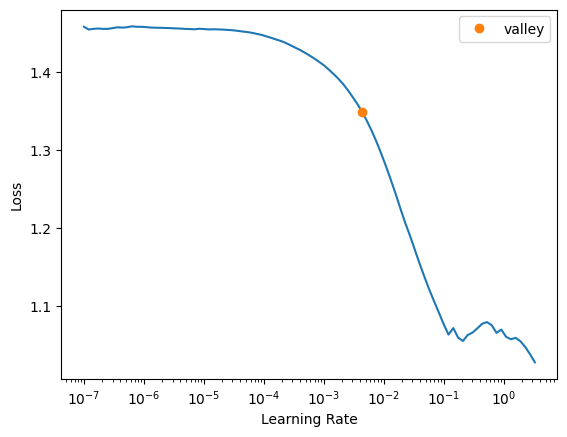

In [ ]:
learn.lr_find()

In [ ]:
lr = 1e-3

In [ ]:
best_model_fname = "best_heart_patch"
save_best = EMACheckpoint(
    monitor='accumulated_dice',
    momentum=0.9,
    comp=np.greater,
    fname=best_model_fname,
    with_opt=False
)

In [ ]:
# All params (size, transforms, loss, model name, etc.) are extracted from learn automatically
mlflow_callback = create_mlflow_callback(learn, experiment_name="Task02_Heart_Patch", dataset_version=med_dataset.fingerprint)
learn.fit_one_cycle(30 , lr, cbs=[mlflow_callback, save_best])

2026/02/16 10:14:50 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/16 10:14:50 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Logged train/val split (14 rows) to MLflow artifacts


epoch,train_loss,valid_loss,accumulated_dice,time
0,1.403591,1.373622,0.037273,00:13
1,1.343610,1.272101,0.043233,00:12
2,1.263287,1.122760,0.065420,00:14
3,1.147556,0.921568,0.178511,00:14
4,0.999787,0.741737,0.254634,00:13
5,0.853500,0.619298,0.342739,00:14
6,0.727886,0.544482,0.372379,00:14
7,0.630917,0.480319,0.423887,00:14
8,0.545285,0.469157,0.369509,00:14
9,0.472616,0.434741,0.391932,00:14



Training finished. Logging model artifacts to MLflow...
Logged best model weights: best_weights.pth
Logged final epoch learner: final_learner.pkl


Saved file doesn't contain an optimizer state.
2026/02/16 10:21:37 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Loaded best model weights (best_heart_patch) for best learner export
Logged best epoch learner: best_learner.pkl
MLflow run completed. Run ID: 18e551181ff340409680b4daf641ab7b


Registered model 'UNet' already exists. Creating a new version of this model...
Created version '20' of model 'UNet'.


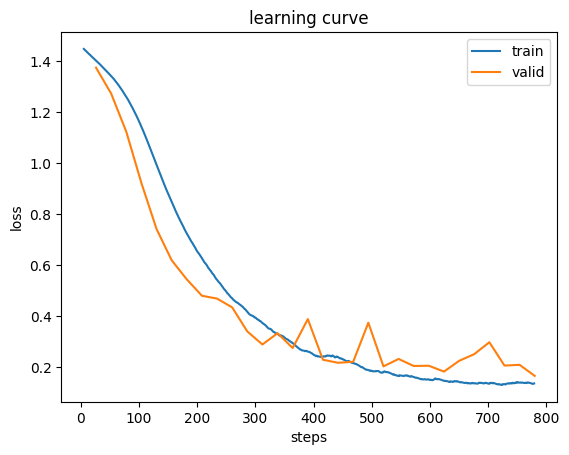

In [ ]:
learn.recorder.plot_loss();

### Save configuration for inference

The following parameters **MUST be identical** between training and inference:
- `apply_reorder`: Whether to reorder to RAS+ orientation
- `target_spacing`: Target voxel spacing for resampling
- `pre_patch_tfms`: Preprocessing transforms (e.g., `ZNormalization`)

Save these to a pickle file for the inference notebook to load.

In [ ]:
store_patch_variables(
    pkl_fn='patch_config.pkl',
    patch_size=patch_config.patch_size,
    patch_overlap=patch_config.patch_overlap,
    aggregation_mode=patch_config.aggregation_mode,
    apply_reorder=patch_config.apply_reorder,
    target_spacing=patch_config.target_spacing,
    sampler_type=patch_config.sampler_type,
    label_probabilities=patch_config.label_probabilities,
    samples_per_volume=patch_config.samples_per_volume,
    queue_length=patch_config.queue_length,
    queue_num_workers=patch_config.queue_num_workers,
    keep_largest_component=patch_config.keep_largest_component
)

print("Configuration saved to patch_config.pkl")

Configuration saved to patch_config.pkl


### Evaluate on validation set

Evaluate the trained model on the validation set using sliding-window patch inference.

**Metrics:**
- **DSC**: Dice score - overlap similarity (higher = better)
- **HD95**: 95th percentile Hausdorff distance in voxels (lower = better)
- **Sens**: Sensitivity - true positive rate (higher = better)
- **LDR**: Lesion detection rate (higher = better)
- **RVE**: Relative volume error (0 = optimal, + = over-seg, - = under-seg)

In [ ]:
# Extract file paths from validation subjects
val_subjects = dls.valid.subjects_dataset
val_img_paths = [str(s['image'].path) for s in val_subjects]
val_mask_paths = [str(s['mask'].path) for s in val_subjects]

print(f"Validation set: {len(val_img_paths)} images")

Validation set: 1 images


In [ ]:
# Load the best model (saved by EMACheckpoint based on smoothed accumulated_dice)
learn.load(best_model_fname)
print(f"Loaded best model: {best_model_fname}")
learn.export(f"models/best_learner.pkl")

save_dir = Path('predictions/patch_heart_val')

predictions = patch_inference(
    learner=learn,
    config=patch_config,
    file_paths=val_img_paths,
    pre_inference_tfms=pre_patch_tfms,
    save_dir=str(save_dir),
    progress=True, 
    tta=True
)

print(f"\nSaved {len(predictions)} predictions to {save_dir}/")

Loaded best model: best_heart_patch


Saved file doesn't contain an optimizer state.


Patch inference (TTA):   0%|          | 0/1 [00:00<?, ?it/s]


Saved 1 predictions to predictions/patch_heart_val/


In [ ]:
from fastMONAI.vision_metrics import (calculate_dsc, calculate_haus,
                                       calculate_confusion_metrics,
                                       calculate_lesion_detection_rate,
                                       calculate_signed_rve)

results = []

for i, pred in enumerate(predictions):
    img_name = Path(val_img_paths[i]).name
    gt_path = val_mask_paths[i]

    # Load ground truth with matching preprocessing
    gt = MedMask.create(
        gt_path,
        apply_reorder=patch_config.apply_reorder,
        target_spacing=patch_config.target_spacing
    )

    # Prepare 5D tensors [B, C, D, H, W]
    pred_5d = pred.unsqueeze(0).float()
    gt_5d = gt.data.unsqueeze(0).float()

    # Compute metrics using calculate_* functions (for binary masks)
    dsc = calculate_dsc(pred_5d, gt_5d).mean().item()
    hd95 = calculate_haus(pred_5d, gt_5d).mean().item()
    sens = calculate_confusion_metrics(pred_5d, gt_5d, "sensitivity").nanmean().item()
    ldr = calculate_lesion_detection_rate(pred_5d, gt_5d).nanmean().item()
    rve = calculate_signed_rve(pred_5d, gt_5d).nanmean().item()

    results.append({
        'image': img_name, 'dsc': dsc, 'hd95': hd95,
        'sensitivity': sens, 'ldr': ldr, 'rve': rve
    })

results_df = pd.DataFrame(results)

monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.


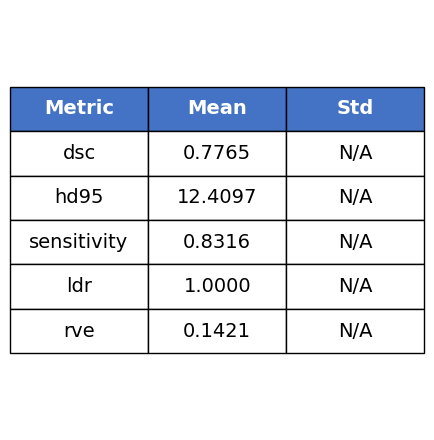

Logged metrics table to MLflow run 18e551181ff340409680b4daf641ab7b
Logged 5 metric(s) to MLflow run 18e551181ff340409680b4daf641ab7b
Logged DataFrame (1 rows) to MLflow run 18e551181ff340409680b4daf641ab7b


In [ ]:
# Log validation metrics to MLflow (metrics auto-inferred from numeric columns)
mlflow_callback.log_metrics_table(results_df, display=True) 
mlflow_callback.log_metrics(
    {f'val_{m}': results_df[m].mean() for m in results_df.select_dtypes(include='number').columns}
)
mlflow_callback.log_dataframe(results_df)

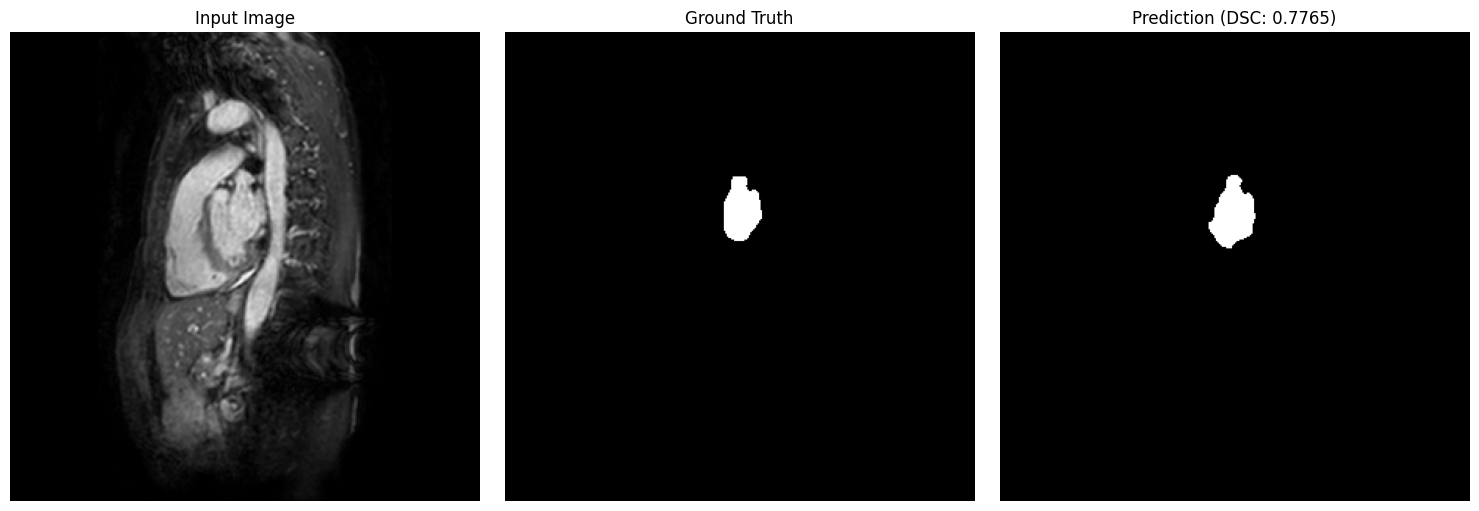

In [ ]:
from fastMONAI.vision_plot import show_segmentation_comparison

idx = 0
val_img = MedImage.create(
    val_img_paths[idx],
    apply_reorder=patch_config.apply_reorder,
    target_spacing=patch_config.target_spacing
)
val_gt = MedMask.create(
    val_mask_paths[idx],
    apply_reorder=patch_config.apply_reorder,
    target_spacing=patch_config.target_spacing
)

show_segmentation_comparison(
    image=val_img,
    ground_truth=val_gt,
    prediction=predictions[idx],
    metric_value=results_df.iloc[idx]['dsc'],
    voxel_size=patch_config.target_spacing,
    anatomical_plane=2  # axial view
)

### View experiment tracking

In [ ]:
mlflow_ui = MLflowUIManager()
mlflow_ui.start_ui()

True

### Summary

In this tutorial, we demonstrated patch-based training and evaluation for 3D medical image segmentation:

**Training:**
1. **`PatchConfig`**: Centralized configuration for patch size, sampling, and inference parameters
2. **`MedPatchDataLoaders`**: Memory-efficient lazy loading with TorchIO Queue
3. **Two-stage transforms**: `pre_patch_tfms` (full volume) + `patch_tfms` (training augmentation)
4. **`AccumulatedDice`**: nnU-Net-style accumulated metric for reliable validation
5. **`store_patch_variables()`**: Save configuration for inference consistency

**Evaluation:**
6. **`patch_inference()`**: Batch sliding-window inference with NIfTI output
7. **Comprehensive metrics**: DSC, HD95, Sensitivity, LDR, RVE

**Key takeaway**: Preprocessing parameters (`apply_reorder`, `target_spacing`, `pre_inference_tfms`) **MUST match** between training and inference for correct predictions.

In [ ]:
mlflow_ui.stop()